# AlexNet Testing
## Initialise dependencies

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import alexnet

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    balanced_accuracy_score
)

DATA_ROOT = Path(r"~/dataset/sampled_1000")

TEST_DIR = DATA_ROOT / "val"
print(TEST_DIR)
MODEL_PATH = "inat_alexnet_1000_npclasses_imagenet.pth"
# MODEL_PATH = "inat_alexnet_1000_ptclasses_imagenet.pth"
print(MODEL_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

~/dataset/sampled_1000/val
inat_alexnet_1000_npclasses_imagenet.pth
Device: cuda


## Confirm Num Classes



In [2]:

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

classes = checkpoint["classes"]
num_classes = checkpoint["num_classes"]

print("Number of classes:", num_classes)
print("Classes:", classes)

Number of classes: 1000
Classes: ['00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii', '00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus', '00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica', '00018_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Argiope_bruennichi', '00024_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Cyclosa_turbinata', '00030_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Larinioides_cornutus', '00038_Animalia_Arthropoda_Arachnida_Araneae_Araneidae_Neoscona_crucifera', '00052_Animalia_Arthropoda_Arachnida_Araneae_Corinnidae_Nyssus_coloripes', '00055_Animalia_Arthropoda_Arachnida_Araneae_Filistatidae_Kukulcania_hibernalis', '00061_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Oxyopes_salticus', '00063_Animalia_Arthropoda_Arachnida_Araneae_Oxyopidae_Peucetia_viridans', '00105_Animalia_Arthropoda_Arachnida_Araneae_Sparassidae_Olios_giganteus', '00116_Animalia_Arthropoda_Arachnida_A

## Create Test transforms and load dataset

In [3]:
INPUT_SIZE = 320
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize(
        352,
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True
    ),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=test_transform)

assert test_dataset.classes == classes, (
    "different testing set"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Test images:", len(test_dataset))

Test images: 10000


## Load in raw alexnet model

In [4]:
model = alexnet(weights=None)
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


## Generate Test Accuracy

In [5]:
correct = 0
total = 0

all_probs = []
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)
        
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        all_probs.append(probs.cpu())
        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        
test_accuracy = correct / total

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Correct predictions: {correct}/{total}")

Test accuracy: 0.1529
Correct predictions: 1529/10000


## Use SKLearn metrics

In [6]:
y_true = np.array(all_labels)
y_predictions = np.array(all_predictions)
all_probs = torch.cat(all_probs).numpy()

top5_accuracy = top_k_accuracy_score(
    y_true, all_probs, k=5, labels=list(range(num_classes))
)

macro_precision = precision_score(
    y_true, y_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true, y_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true, y_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true, y_predictions,
    average="weighted",
    zero_division=0
)

balance_accuracy = balanced_accuracy_score(y_true, y_predictions)

print(f"Top-1 Accuracy:    {test_accuracy:.4f}")
print(f"Top5 Accuracy:    {top5_accuracy:.4f}")
print(f"Macro Precision:  {macro_precision:.4f}")
print(f"Macro Recall:     {macro_recall:.4f}")
print(f"Macro F1:         {macro_f1:.4f}")
print(f"Weighted F1:      {weighted_f1:.4f}")
print(f"Balanced Accuracy:      {balance_accuracy:.4f}")

Top-1 Accuracy:    0.1529
Top5 Accuracy:    0.3154
Macro Precision:  0.1555
Macro Recall:     0.1529
Macro F1:         0.1475
Weighted F1:      0.1475
Balanced Accuracy:      0.1529


## Display Confusion Matrix

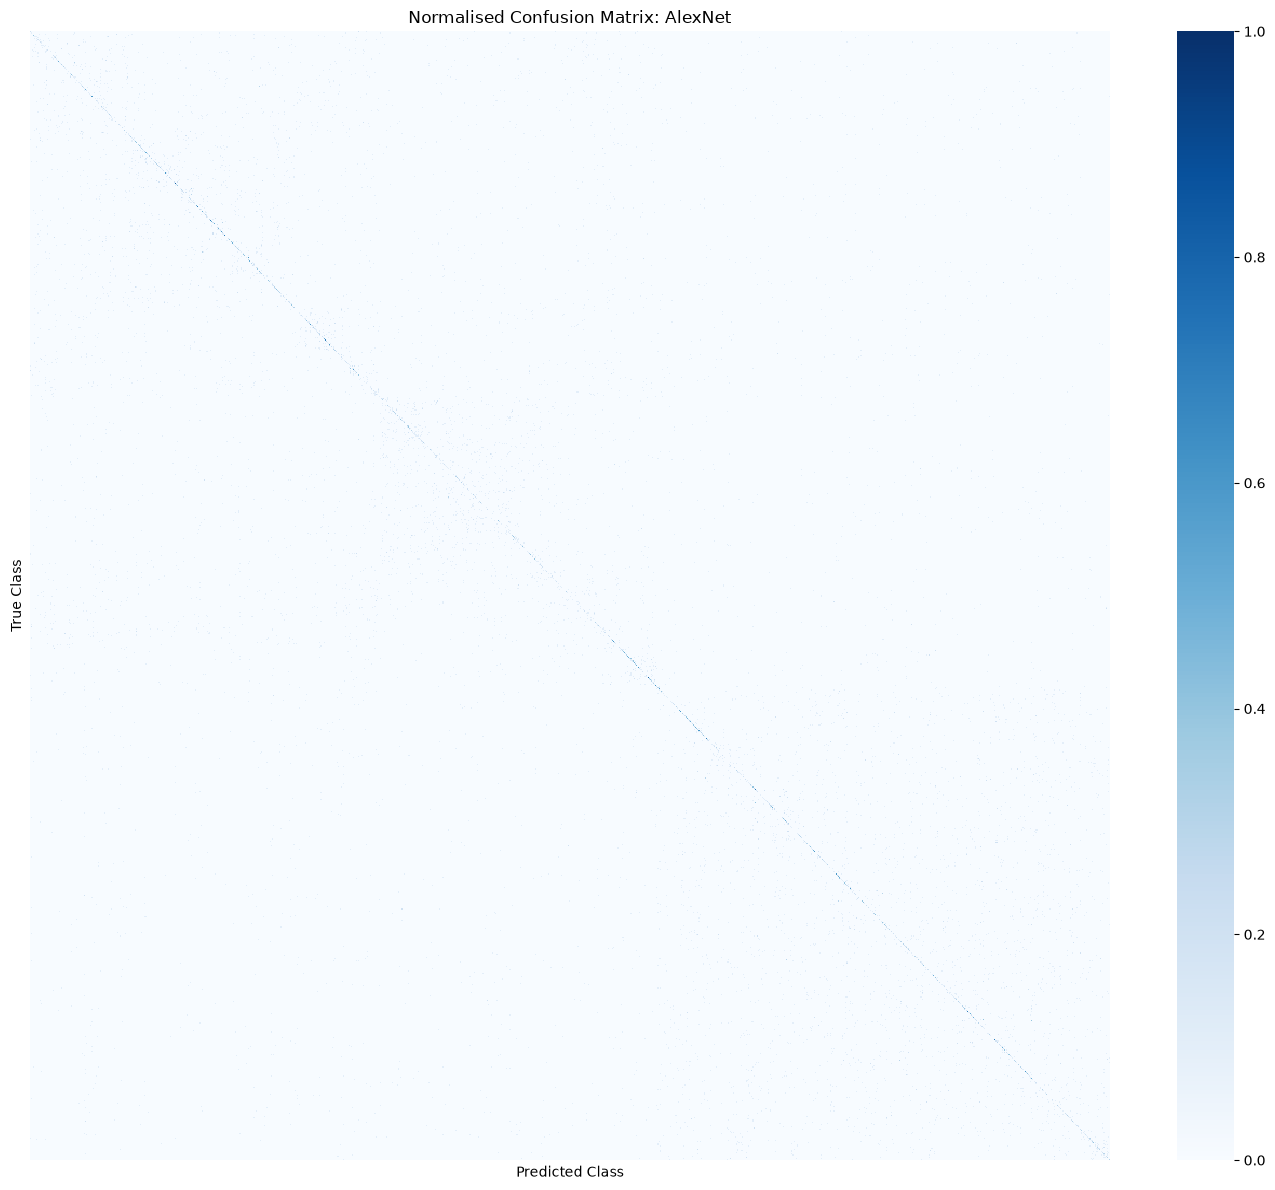

In [7]:
class_names = test_dataset.classes
num_classes = len(class_names)

cm_normalized = confusion_matrix(
    y_true,
    y_predictions,
    labels=range(num_classes),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(14,12))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

ax.set_title("Normalised Confusion Matrix: AlexNet")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

fig.tight_layout()
plt.show()